In [6]:
%pip install skyfield
%pip install matplotlib
%pip install cartopy

Thu Apr  9 12:36:36 CDT 2026
Note: you may need to restart the kernel to use updated packages.
Thu Apr  9 12:36:38 CDT 2026
Note: you may need to restart the kernel to use updated packages.
Thu Apr  9 12:36:39 CDT 2026
  Using cached Cartopy-0.19.0.post1.tar.gz (12.1 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... error
  ERROR: Command errored out with exit status 1:
   command: /proj/ksims/Classwork_ml/Tasking_Manager/.venv/bin/python /proj/ksims/Classwork_ml/Tasking_Manager/.venv/lib64/python3.6/site-packages/pip/_vendor/pep517/in_process/_in_process.py get_requires_for_build_wheel /tmp/tmpqwkti1cr
       cwd: /tmp/pip-install-ax8qt8_q/cartopy_0e481bda0dce4fb99fe6a2b062fcf8d1
  Complete output (3 lines):
  setup.py:120: UserWarning: Unable to determine GEOS version. Ensure you have 3.3.3 or later installed, or installation may fail.
    '.'.join(str(v) for v in GEOS_MIN_VERSION), ))
  Proj 4.9.0 must be installed.
  ----------------------------

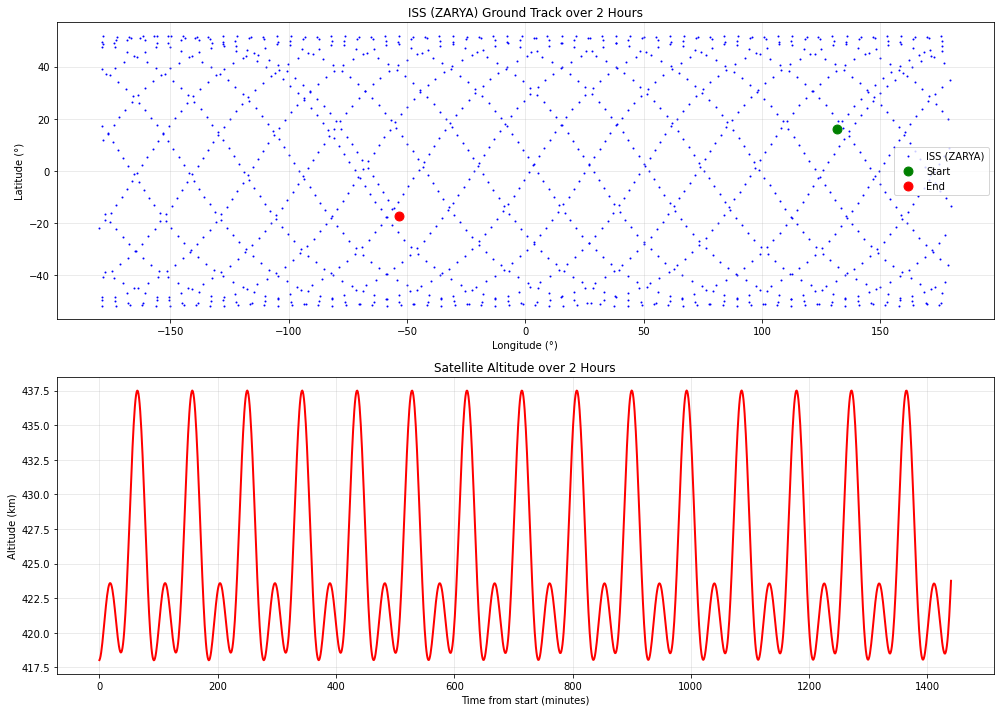

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skyfield.api import load, wgs84, EarthSatellite
from datetime import datetime, timedelta

# ==================== CONFIG ====================
# Paste your TLE here (Line 0 optional, Line 1 and Line 2 required)
tle_lines = [
    "ISS (ZARYA)",
    "1 25544U 98067A   26097.12345678  .00001534  00000-0  35580-4 0  9999",
    "2 25544  51.6416 247.4627 0001671  64.9808 295.1027 15.49338189 99999"
]

satellite_name = tle_lines[0].strip()
line1 = tle_lines[1]
line2 = tle_lines[2]

# Time range: now + 2 hours, with 1-minute steps
ts = load.timescale()
t0 = ts.now()                                   # current UTC time
t1 = ts.utc(t0.utc_datetime() + timedelta(hours=24))  # 24 hours later

# Create evenly spaced times (every 60 seconds)
numpts = int((t1.utc_datetime() - t0.utc_datetime()).total_seconds() / 60) + 1
times = ts.linspace(t0, t1, num=numpts)            # 121 points = 2 hours at 1-min interval

# ==================== COMPUTE POSITIONS ====================
satellite = EarthSatellite(line1, line2, satellite_name, ts)

# Get geocentric position at all times
geocentric = satellite.at(times)

# Convert to latitude, longitude, and height (km)
lat = wgs84.latlon_of(geocentric)[0].degrees
lon = wgs84.latlon_of(geocentric)[1].degrees
height_km = wgs84.height_of(geocentric).km

# ==================== PLOTS ====================

plt.figure(figsize=(14, 10))

# Plot 1: Ground Track (Latitude vs Longitude)
plt.subplot(2, 1, 1)
plt.scatter(lon, lat, c='blue', s=1, label=satellite_name)
plt.scatter(lon[0], lat[0], color='green', s=80, label='Start')
plt.scatter(lon[-1], lat[-1], color='red', s=80, label='End')

plt.xlabel('Longitude (°)')
plt.ylabel('Latitude (°)')
plt.title(f'{satellite_name} Ground Track over 2 Hours')
plt.grid(True, alpha=0.3)
plt.legend()

# Plot 2: Altitude over Time
plt.subplot(2, 1, 2)
minutes = np.linspace(0, numpts - 1, len(times))   # minutes from start
plt.plot(minutes, height_km, 'r-', linewidth=2)
plt.xlabel('Time from start (minutes)')
plt.ylabel('Altitude (km)')
plt.title('Satellite Altitude over 2 Hours')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ==================== TLE DATA ====================
tle_lines = [
    "STARLINK-35224",
    "1 65811U 25218W   26097.60955005  .00006254  00000-0  43716-3 0  9994",
    "2 65811  97.6024 321.4932 0003219  68.8995 291.2576 15.05655268 29326"
]

# Load timescale and create satellite object
ts = load.timescale()
satellite = EarthSatellite(tle_lines[1], tle_lines[2], tle_lines[0], ts)

# Time range: now → now + 2 hours (every 60 seconds)
t0 = ts.now()
t1 = ts.utc(t0.utc_datetime() + timedelta(hours=2))
times = ts.linspace(t0, t1, num=121)   # 121 points = 2 hours @ 1 min steps

# Compute positions
geocentric = satellite.at(times)
lat = wgs84.latlon_of(geocentric)[0].degrees
lon = wgs84.latlon_of(geocentric)[1].degrees
height_km = wgs84.height_of(geocentric).km

# ==================== PLOTS ====================
plt.figure(figsize=(14, 10))

# Ground Track
plt.subplot(2, 1, 1)
plt.plot(lon, lat, 'b-', linewidth=2, label='STARLINK-35224')
plt.scatter(lon[0], lat[0], color='green', s=100, label='Start (Now)')
plt.scatter(lon[-1], lat[-1], color='red', s=100, label='End (+2h)')

plt.xlabel('Longitude (°)')
plt.scatter(lon[0], lat[0], color='green', s=100, label='Start (Now)')
plt.scatter(lon[-1], lat[-1], color='red', s=100, label='End (+2h)')
plt.ylabel('Latitude (°)')
plt.title('STARLINK-35224 Ground Track – Next 2 Hours')
plt.grid(True, alpha=0.3)
plt.legend()

# Altitude over time
plt.subplot(2, 1, 2)
minutes = np.linspace(0, 120, len(times))
plt.plot(minutes, height_km, 'r-', linewidth=2)
plt.xlabel('Time from now (minutes)')
plt.ylabel('Altitude (km)')
plt.title('Altitude Variation over Next 2 Hours')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Dictionary of continents with lists of (longitude, latitude) points
# These are simplified but much better than the rough version
continents = {
    "North America": [
        (-170, 65), (-130, 70), (-100, 70), (-80, 55), (-55, 50), (-80, 25),
        (-120, 15), (-140, 60), (-170, 65)
    ],
    "South America": [
        (-80, 12), (-70, 10), (-60, -5), (-50, -10), (-40, -20), (-35, -55),
        (-70, -50), (-75, -15), (-80, 12)
    ],
    "Europe": [
        (-10, 70), (5, 65), (30, 70), (40, 65), (30, 40), (20, 35),
        (-10, 35), (-10, 55), (-10, 70)
    ],
    "Africa": [
        (-20, 35), (10, 37), (35, 30), (50, 10), (45, -10), (40, -35),
        (20, -35), (10, -10), (-20, 0), (-20, 35)
    ],
    "Asia": [
        (25, 80), (60, 80), (120, 75), (180, 65), (170, 60), (140, 35),
        (120, 10), (95, 5), (70, 20), (60, 35), (25, 40), (25, 80)
    ],
    "Australia": [
        (113, -10), (153, -10), (155, -38), (145, -45), (130, -38),
        (113, -20), (113, -10)
    ],
    "Antarctica": [
        (-180, -60), (-150, -70), (-120, -75), (-90, -85), (-60, -75),
        (-30, -70), (0, -65), (30, -70), (60, -75), (90, -85),
        (120, -75), (150, -70), (180, -60), (-180, -60)
    ]
}

# Create the plot
fig, ax = plt.subplots(figsize=(14, 9))

colors = ['#2E8B57', '#4682B4', '#32CD32', '#DAA520', '#CD853F', '#8B4513', '#A9A9A9']

for i, (name, points) in enumerate(continents.items()):
    # Close the polygon by appending the first point
    x, y = zip(*points)
    x = list(x) + [x[0]]
    y = list(y) + [y[0]]
    
    # Plot the outline with fill
    ax.fill(x, y, color=colors[i], alpha=0.7, edgecolor='black', linewidth=1.2, label=name)
    ax.plot(x, y, color='black', linewidth=1.5)

# Improve the map appearance
ax.set_xlabel("Longitude", fontsize=12)
ax.set_ylabel("Latitude", fontsize=12)
ax.set_title("Continent Outlines - Pure Matplotlib (Detailed Version)", fontsize=16, pad=20)

ax.grid(True, linestyle='--', alpha=0.5)
ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)

# Add equator and prime meridian for reference
ax.axhline(0, color='gray', linestyle='-', alpha=0.6, linewidth=0.8)
ax.axvline(0, color='gray', linestyle='-', alpha=0.6, linewidth=0.8)

ax.legend(loc='lower left', fontsize=10, frameon=True)
plt.tight_layout()
plt.show()

In [5]:
from skyfield.api import load, wgs84, EarthSatellite
from datetime import datetime, timedelta
import matplotlib.pyplot as plt


# Load timescale
ts = load.timescale()

# === Replace with your actual TLEs ===
tle1_line1 = "1 44736U 19074Z   26097.35353354  .01867322  11831-4  88106-3 0  9993"
tle1_line2 = "2 44736  53.0269 331.6642 0006106 247.2484 112.7909 16.20801303354285"

tle2_line1 = "1 44927U 20001P   26097.25569694  .00137657  00000+0  19301-2 0  9993"
tle2_line2 = "2 44927  53.0458 191.7053 0004221 264.9325  95.1204 15.55812432344535"

sat1 = EarthSatellite(tle1_line1, tle1_line2, name="Sat1", ts=ts)
sat2 = EarthSatellite(tle2_line1, tle2_line2, name="Sat2", ts=ts)

# Choose a time (or a range of times)
t = ts.now()                                 # current time
# t = ts.utc(2026, 4, 10, 12, 30, 0)        # specific UTC time

# Get positions relative to the center of the Earth
pos1 = sat1.at(t)      # Geocentric position of Sat1
pos2 = sat2.at(t)      # Geocentric position of Sat2

# Create a vector from Sat1 → Sat2
vector_from_sat1_to_sat2 = pos2 - pos1

# Check if the Earth blocks the line of sight from Sat1's perspective
# (is_behind_earth() returns True if the target is occulted by Earth)
blocked = vector_from_sat1_to_sat2.is_behind_earth()

print(f"At {t.utc_strftime('%Y-%m-%d %H:%M:%S UTC')}:")
print(f"  Distance: {vector_from_sat1_to_sat2.distance().km:.1f} km")
print(f"  In view (line-of-sight clear)? → {'Yes' if not blocked else 'No (Earth blocks)'}")


ValueError: can only compute Earth occultation for positions observed from an Earth satellite

In [4]:
test = "1"
test = test.ljust(70)
print(test)
print(len(test))
test[5:10] = "ABCDE"
print(test)

1                                                                     
70


TypeError: 'str' object does not support item assignment